# Numerical Linear Regression

## Steps

1. Gradient descent with one variable
2. Newton method with one variable
3. Gradient descent with two (and more) variables
4.  Newton method with two (and more) variables

### Importing all sublibraries

For the upcoming tasks I will be using Numpy 2.4.4 and matplotlib 3.10.8

In [28]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np

print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {mpl.__version__}")

NumPy version: 1.26.4
Matplotlib version: 3.10.8


## Gradient descent with one variable 

Let us start a simple linear model $Y = aX$ with one feature $X$ and one response $Y$, a slope of $a$ that is to be learned assuming an intercept $b=0$.

We generate data for $Y=2X, X\in [1,10]$ with a random error that is normally distributed proportional to $\mathcal{N}(0,10)$. 

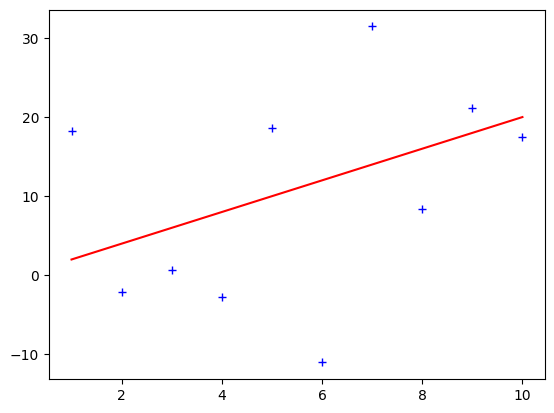

In [29]:
np.random.seed(1)

N = 10
a0 = 2
X = np.linspace(1, N, N)
Y = a0 * X + np.random.normal(loc=0, scale=10, size=N)

plt.figure(1)
plt.plot(X, Y, "b+")
plt.plot(X, a0*X, "r-")
plt.show()

We learn $\hat a$ (parameter, weight) from the data and expect it to be $\approx 2$. Therefore, we minimize the residual sum of squares as our optimization goal (loss, error) function, i.e., $\hat a = \min \arg RSS(a)$ where $RSS(a) =\sum_{i=1}^{n}(y_i - a x_i)^2$.  

For the sake of demonstrating the numerical approach, we deliberately ignore that an analytic solution exists. 

Let's define and plot $RSS$ as a function of $a$. We chose the range of $a$ around the (actually unknown) minimum of $\approx 2$. 

In [30]:
def rss(a, X, Y):
	n = len(X)
	err = 0
	for i in range(n):
		err += (Y[i] - a*X[i])**2
	return err

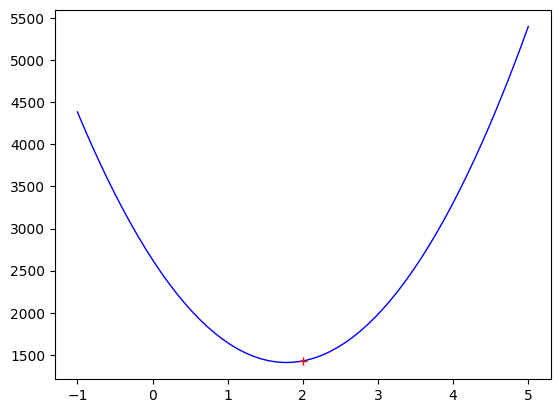

In [31]:
a_range = np.linspace(a0-3, a0+3, 60)
plt.figure(2)
plt.plot(a_range, rss(a_range, X, Y), "b-", linewidth=1)
plt.plot(a0, rss(a0, X, Y), "r+")
plt.show()

The gradient of $RSS(a)$ for any $a$ is defiend as:

$$
\begin{aligned}
\nabla RSS(a) &= \frac{\partial RSS(a)}{\partial a}\\
&=\frac{\partial \sum_{i=1}^{n}(y_i- a x_i)^2}{\partial a}\\
&=\sum_{i=1}^{n}2(y_i- a x_i)(-x_i)\\
&=-2\sum_{i=1}^{n}(y_i- a x_i)x_i
\end{aligned}
$$

In [32]:
def grad_rss(a, X, Y):
    n = len(X)
    grad_err = 0
    for i in range(n):
        grad_err += (Y[i] - a*X[i])*X[i]
    grad_err *= -2
    return grad_err

169.12151983231877


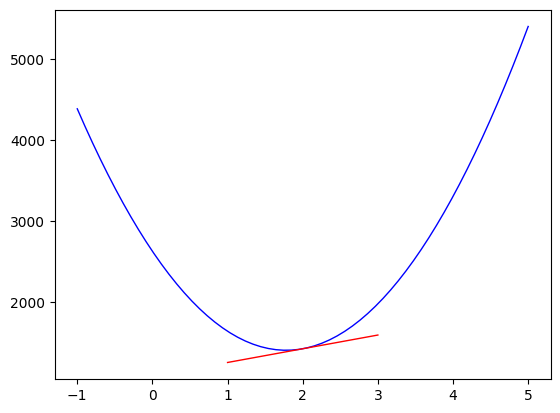

In [33]:
grad_a_range = np.linspace(a0-1, a0+1, 20)
print(grad_rss(a0, X, Y))

plt.figure(3)
plt.plot(a_range, rss(a_range, X, Y), "b-", linewidth=1)
plt.plot(grad_a_range, (grad_a_range - a0) * grad_rss(a0, X, Y) + rss(a0, X, Y), "r-", linewidth=1)
plt.show()

We iteratively approximate $\hat a$ with gradient descent, i.e., starting with an initial guess $a_0$ and a learning rate of $\varepsilon$ we iterate over

$$
\begin{aligned}
a_{k+1} &= a_k - \varepsilon \nabla RSS(a_k) \\
&= a_k + 2 \varepsilon \sum_{i=1}^{n}(y_i- a_k x_i)x_i
\end{aligned}
$$

In [34]:
def grad_desc_rss(K, a0, X, Y, learning_eps, verbose):
    a = np.zeros((K+1, 1))
    a[0] = a0

    if verbose:
        plt.figure()

    for k in range(K):
        a[k + 1] = a[k] - learning_eps * grad_rss(a[k], X, Y)
        if verbose:
            plt.plot([a[k], a[k+1]], [rss(a[k], X, Y), rss(a[k+1], X, Y)], "k-", linewidth=1)
            plt.plot(a[k + 1], rss(a[k], X, Y), "kx")
    if verbose:
        a_range = np.linspace(np.min(a) - 1, np.max(a) + 1, 1000)
        plt.plot(a_range, rss(a_range, X, Y), "b-", linewidth=1)
        grad_a_range = np.linspace(a0-1, a0+1, 1000)
        plt.plot(grad_a_range, (grad_a_range - a0) * grad_rss(a0, X, Y) + rss(a0, X, Y), "r-", linewidth=1)
        k_range = np.linspace(a[K] - 1, a[K] + 1, 1000)
        plt.plot(k_range, (k_range - a[K]) * grad_rss(a[K], X, Y) + rss(a[K], X, Y), "y-", linewidth=1)
        plt.show()
    return a
        

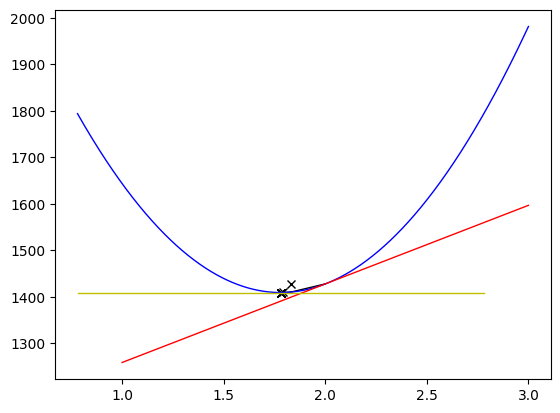

In [35]:
K = 10
learning_eps = 0.001
# learning_eps = 0.0001
# learning_eps = 0.003
a = grad_desc_rss(K, a0, X, Y, learning_eps, verbose=True)

*Try different learning rates and interpret the effect. Your answer goes here!*

Depending on the learning rate, the "optimal" $\hat{a}$ converges faster or slower, or diverges alltogether."

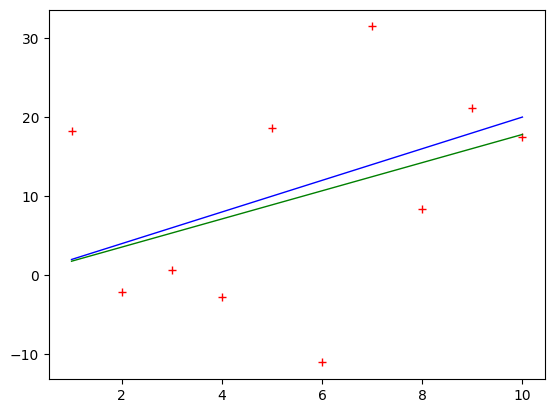

In [36]:
plt.figure(5)
plt.plot(X, Y, "r+")
plt.plot(X, a0*X, "b-", linewidth=1)
plt.plot(X, a[K]*X, "g-", linewidth=1)
plt.show()

## Newton method with one variable

It is obviously difficult to set the learning rate right. To help this, the Newton method adjusts the learning rate $\varepsilon$ in each step to $1/h(a_i)$, i.e., the inverse of the second derivative $h(a)$ of the loss function at the current location $a_i$. In our case it is the inverse of the second derivative of $RSS$.

$$
\begin{aligned}
h(a) &= \frac{\partial^2 RSS(a)}{\partial a^2}\\
&=\frac{\partial (-2 \sum_{i=1}^{n}(y_i- a x_i)x_i)}{\partial a}\\
&=2\sum_{i=1}^{n}x_i^2\\
\end{aligned}
$$

We observe, that $h$ is a constant w.r.t. $a$ and, hence, it does not change during iteration in our quadratic optimization case.

In [37]:
h = 2*np.sum(X*X)
learning_eps = 1/h
print(learning_eps)

0.0012987012987012987


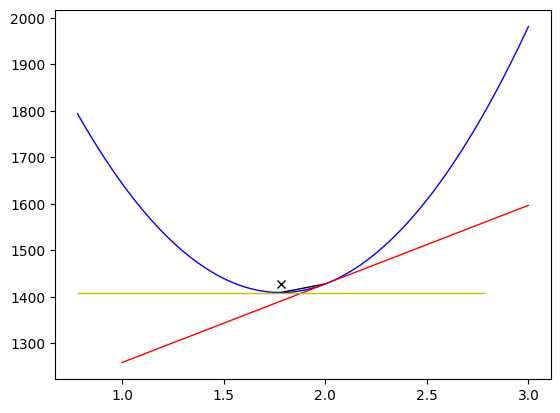

array([[2.        ],
       [1.78036166]])

In [38]:
grad_desc_rss(1, a0, X, Y, learning_eps, verbose=True)

## Gradient descent with two (and more) variables

Let us add an intercept to the linear model $Y = aX +b$ still with one feature $X$ and one response $Y$, but with slope $a$ and intercept $b$ to be learned.

We generate data for $Y=2X - 3$ with a random error that is normally distributed proportional to $\mathcal{N}(0,10)$. 

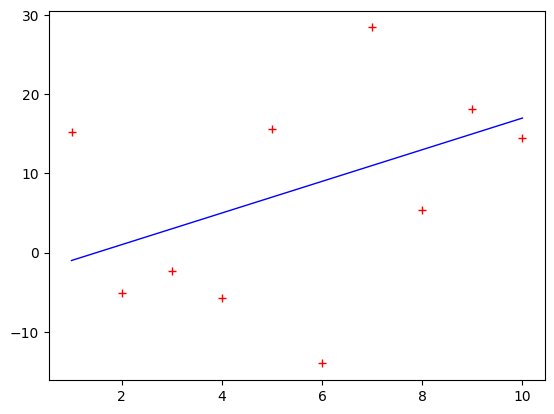

In [39]:
np.random.seed(1)
a0 = 2
b0 = -3
X = np.linspace(1, N, N)
Y = a0 * X + b0 + np.random.normal(loc=0, scale=10, size=N)

plt.figure(6)
plt.plot(X, Y, "r+")
plt.plot(X, a0 * X + b0, "b-", linewidth=1)
plt.show()

We learn $\hat a$ and $\hat b$ from the data and expect them to be $\approx 2$ and $\approx -3$, respectively. 
Therefore, we minimize the residual sum of squares $RSS=\sum_{i=1}^{n}(y_i-\hat a x_i - \hat b)^2$.  

Let's define and 3D-plot the modified $RSS$ as a function of $a$ and $b$. We chose the ranges of $a$ and $b$ around the (actually unknown) expected minima of $\approx 2$ and $\approx -3$, respectively. 

In [40]:
def rss2(a, b, X, Y):
    n = len(X)
    err = 0
    for i in range(n):
        err += (Y[i] - a*X[i] - b)**2
    return err

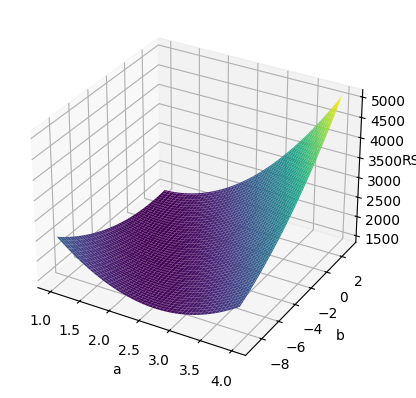

In [41]:
[A, B] = np.meshgrid(np.linspace(a0-1, a0+2, 100), np.linspace(b0-6, b0+6, 100))


fig = plt.figure(7)
ax = plt.axes(projection="3d")
ax.plot_surface(A, B, rss2(A, B, X, Y), cmap="viridis")
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_zlabel("RSS")
plt.show()

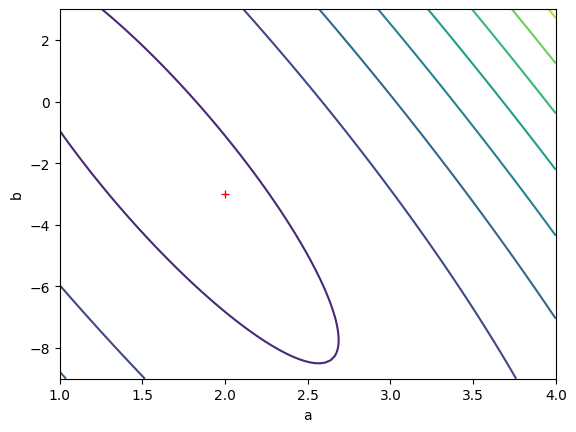

In [42]:
fig = plt.figure(8)
ax = plt.axes()
ax.contour(A, B, rss2(A, B, X, Y), cmap="viridis")
ax.plot(a0, b0, "r+")
ax.set_xlabel("a")
ax.set_ylabel("b")
plt.show()

*What can you say about the loss function space? Your answer goes here.*

The loss space for 2 parameters seems to be convex and xhould work nicely to optimize on. It also doesn't look that steep near the minimum, so it might require more iterations/higer learning rate to arrive.

The gradient of $RSS(a,b)$ for any $a, b$ is defiend as:

$$
\begin{aligned}
\nabla RSS(a,b) &= \left [ \frac{\partial RSS(a,b)}{\partial a}, \frac{\partial RSS(a,b)}{\partial b}\right ]^T\\
&= \left [ \frac{\partial \sum_{i=1}^{n}(y_i- a x_i-b)^2}{\partial a}, 
           \frac{\partial \sum_{i=1}^{n}(y_i- a x_i-b)^2}{\partial b}\right ]^T \\
&= \left [ \sum_{i=1}^{n}2(y_i- a x_i-b)(-x_i),\sum_{i=1}^{n}2(y_i- a x_i-b)(-1) \right ]^T \\
&= \left [ -2\sum_{i=1}^{n}(y_i- a x_i-b)x_i,-2\sum_{i=1}^{n}(y_i- a x_i-b) \right ]^T \\
&= -2 \left [ \sum_{i=1}^{n}(y_i- a x_i-b)x_i, \sum_{i=1}^{n}(y_i- a x_i-b) \right ]^T 
\end{aligned}
$$

In [43]:
def grad_rss2(a, b, X, Y):
    n = len(X)
    grad_a = 0
    grad_b = 0
    for i in range(n):
        tmp = Y[i] - a*X[i] - b
        grad_a += tmp * X[i]
        grad_b += tmp
    grad_a = grad_a * -2
    grad_b = grad_b * -2
    grad_w = [grad_a, grad_b]
    return grad_w

In [44]:
def grad_desc_rss2(K, a0, b0, X, Y, learning_eps, verbose):
    a = np.zeros((K+1,1))
    b = np.zeros((K+1,1))
    a[0] = a0
    b[0] = b0

    if verbose:
        plt.figure()
        plt.plot(a0, b0, "ro")

    for k in range(K):
        [grad_a, grad_b] = grad_rss2(a[k], b[k], X, Y)
        a[k+1] = a[k] - learning_eps * grad_a
        b[k+1] = b[k] - learning_eps * grad_b

        if verbose:
            plt.plot([a[k], a[k+1]], [b[k], b[k+1]], "r-")
            plt.plot(a[k+1], b[k+1], "ro")

    if verbose:
        alow = np.min(a)
        alow = np.min([alow, a0-2])
        ahigh = np.max(a)
        ahigh = np.max([ahigh, a0+2])
        blow = np.min(b)
        blow = np.min([blow, b0-9])
        bhigh = np.max(b)
        bhigh = np.max([bhigh, b0+9])
        [A, B] = np.meshgrid(np.linspace(alow, ahigh, 100), np.linspace(blow, bhigh, 100))
        plt.contour(A, B, rss2(A, B, X, Y), cmap="viridis")
        plt.show()
    
    return [a, b]

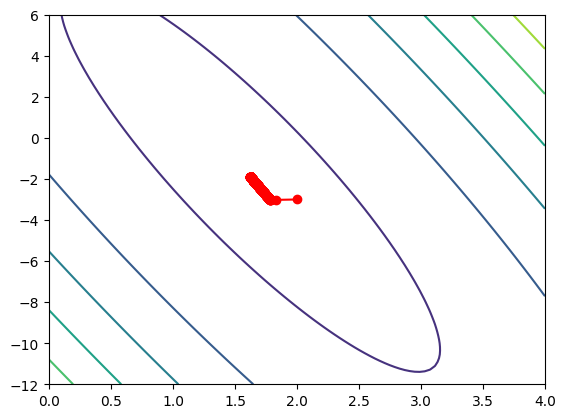

In [45]:
K = 1000
learning_eps = 0.001
# learning_eps = 0.0001
# learning_eps = 0.0025
# learning_eps = 0.00255

[a, b] = grad_desc_rss2(K, a0, b0, X, Y, learning_eps, verbose=True)

*Try different learning rates and interpret the effect. Your answer goes here!*

The gradient descent for more than one variable/parameter seems to work fine with the implementation used. Higher learning rates seem to jump around the minima while smaller learning rates seem to take longer/more iterations to arive if at all.

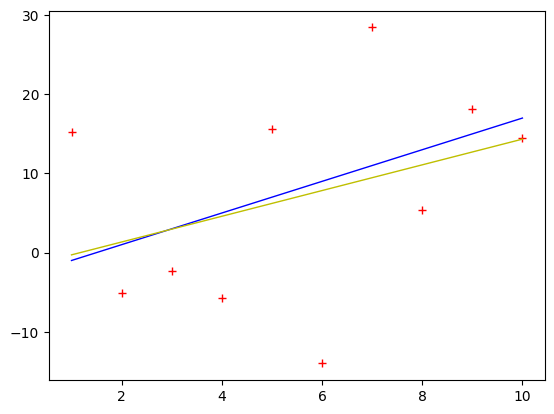

In [46]:
fig = plt.figure(10)
ax = plt.axes()
ax.plot(X, Y, "r+")
ax.plot(X, a0 * X + b0, "b-", linewidth=1)
ax.plot(X, a[-1] * X + b[-1], "y-", linewidth=1)
plt.show()

## Newton method with two (and more) variables

It is still difficult to set the learning rate right. To help this, the Newton method for one variable generalizes:

$$
[a_{k+1}, b_{k+1}] = [a_k,b_k] - H_{RSS}(a_k,b_k)^{-1} \nabla RSS(a_k,b_k) 
$$

where $H_{RSS}$ is the Hessian matrix of $RSS$. 

The Hessian matrix is defined as:
$$
\begin{aligned}
H_{RSS}(a,b) &= 
\begin{bmatrix}
\frac{\partial^2 RSS(a,b)}{\partial a^2} & \frac{\partial^2 RSS(a,b)}{\partial a \partial b} \\
\frac{\partial^2 RSS(a,b)}{\partial b \partial a} & \frac{\partial^2 RSS(a,b)}{\partial b^2} 
\end{bmatrix}\\
&=
\begin{bmatrix}
\frac{\partial (-2\sum_{i=1}^{n}(y_i- a x_i-b)x_i)}{\partial a} & \frac{\partial (-2\sum_{i=1}^{n}(y_i- a x_i-b)x_i)}{\partial b} \\
\frac{\partial (-2\sum_{i=1}^{n}(y_i- a x_i-b)) }{\partial a} & \frac{\partial (-2\sum_{i=1}^{n}(y_i- a x_i-b))}{\partial b} 
\end{bmatrix}\\
&=
\begin{bmatrix}
2\sum_{i=1}^{n}x_i^2 & 2\sum_{i=1}^{n}x_i \\
2\sum_{i=1}^{n}x_i & 2n
\end{bmatrix}\\
&=2
\begin{bmatrix}
\sum_{i=1}^{n}x_i^2 & \sum_{i=1}^{n}x_i \\
\sum_{i=1}^{n}x_i & n
\end{bmatrix}\\
\end{aligned}
$$

As in the case for one variable, we observe that $H_{RSS}$ is a constant matrix, i.e., it does not change during the iterations in our quadratic optimization case. 

In [47]:
H = np.zeros((2, 2))
H[0,0] = 2 * np.sum(X**2)
H[0,1] = 2 * np.sum(X)
H[1,0] = 2 * np.sum(X)
H[1,1] = 2 * N

print(H)

H_inv = np.linalg.inv(H)

print(H_inv)

[[770. 110.]
 [110.  20.]]
[[ 0.00606061 -0.03333333]
 [-0.03333333  0.23333333]]


Recall the inverse of a $2\times 2$ matrix $H$: 

$$
\begin{aligned}
H^{-1} &=\frac{1}{h_{11}h_{22}-h_{12}h_{21}}
\begin{bmatrix}
h_{22} & -h_{12} \\
-h_{21} & h_{11} 
\end{bmatrix}\\
\end{aligned}
$$

A learning rate $\varepsilon$ only scales the gradient vector; a Hessian matrix scales and rotates the gradient vector. Check how this concrete Hessian matrix transforms (scales and rotates) a unit vector:

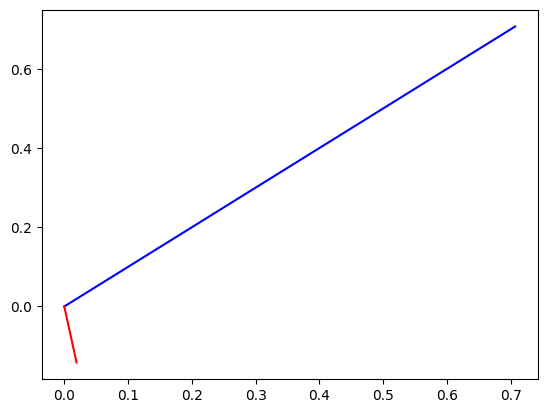

In [48]:
plt.figure(11)
v1 = np.array([[1/np.sqrt(2)], [1/np.sqrt(2)]])
plt.plot([0, v1[0][0]], [0, v1[1][0]], "b-")
v2 = -H_inv @ v1
plt.plot([0, v2[0][0]], [0, v2[1][0]], "r-")
plt.show()

In [49]:
def newton_rss2(K, a0, b0, X, Y, H, verbose):
    H_inv = np.linalg.inv(H)
    ab = np.zeros((K+1, 2))
    ab[0, 0] = a0
    ab[0, 1] = b0

    if verbose:
        plt.figure()

    for k in range(K):
        [grad_a, grad_b] = grad_rss2(ab[k, 0], ab[k, 1], X, Y)
        ab[k+1] = ab[k] - np.array([grad_a, grad_b]) @ H_inv.T
        if verbose:
            plt.plot([ab[k, 0], ab[k+1, 0]], [ab[k, 1], ab[k+1, 1]], "r-")
            plt.plot(ab[k+1, 0], ab[k+1, 1], "ro")
    
    if verbose:
        alow = np.min(ab[:, 0])
        alow = np.min([alow, a0-2])
        ahigh = np.max(ab[:, 0])
        ahigh = np.max([ahigh, a0+2])
        blow = np.min(ab[:, 1])
        blow = np.min([blow, b0-9])
        bhigh = np.max(ab[:, 1])
        bhigh = np.max([bhigh, b0+9])
        [A, B] = np.meshgrid(np.linspace(alow, ahigh, 100), np.linspace(blow, bhigh, 100))
        plt.contour(A, B, rss2(A, B, X, Y), cmap="viridis")
        plt.show()
    return ab

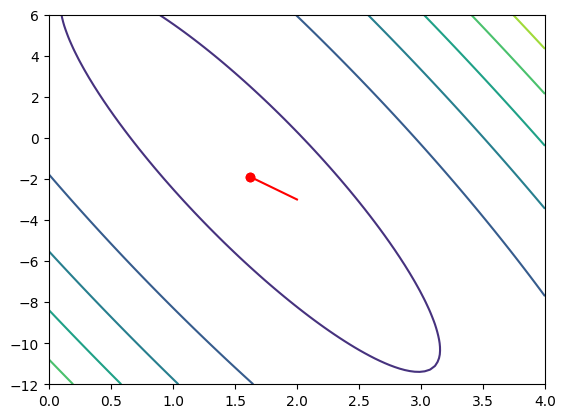

In [50]:
K = 2
ab_newton = newton_rss2(K, a0, b0, X, Y, H, verbose=True)

In [51]:
print(rss2(a0, b0, X, Y))
print(rss2(ab_newton[-1, 0], ab_newton[-1, 1], X, Y))

1427.6757139745007
1406.490506772146


The Newton method could overshoot the minimum (if the loss function is not convex or due to numerical errors). Therefore, the relaxed or damped Newton's method introduces a damping factor $0<\gamma \leq 1$. Also, we exit when we overshoot the optimum.

In [52]:
def damped_newton_rss2(K, a0, b0, X, Y, H, gamma, verbose):
    H_inv = gamma * np.linalg.inv(H)
    ab = np.zeros((K+1, 2))
    ab[0, 0] = a0
    ab[0, 1] = b0

    if verbose:
        plt.figure()

    for k in range(K):
        [grad_a, grad_b] = grad_rss2(ab[k, 0], ab[k, 1], X, Y)
        ab[k+1] = ab[k] - np.array([grad_a, grad_b]) @ H_inv.T
        if rss2(ab[k+1, 0], ab[k+1, 1], X, Y) >= rss2(ab[k, 0], ab[k, 1], X, Y):
            k -= 1
        if verbose:
            plt.plot([ab[k, 0], ab[k+1, 0]], [ab[k, 1], ab[k+1, 1]], "r-")
            plt.plot(ab[k+1, 0], ab[k+1, 1], "ro")
    
    if verbose:
        alow = np.min(ab[:, 0])
        alow = np.min([alow, a0-2])
        ahigh = np.max(ab[:, 0])
        ahigh = np.max([ahigh, a0+2])
        blow = np.min(ab[:, 1])
        blow = np.min([blow, b0-9])
        bhigh = np.max(ab[:, 1])
        bhigh = np.max([bhigh, b0+9])
        [A, B] = np.meshgrid(np.linspace(alow, ahigh, 100), np.linspace(blow, bhigh, 100))
        plt.contour(A, B, rss2(A, B, X, Y), cmap="viridis")
        plt.show()
    return ab

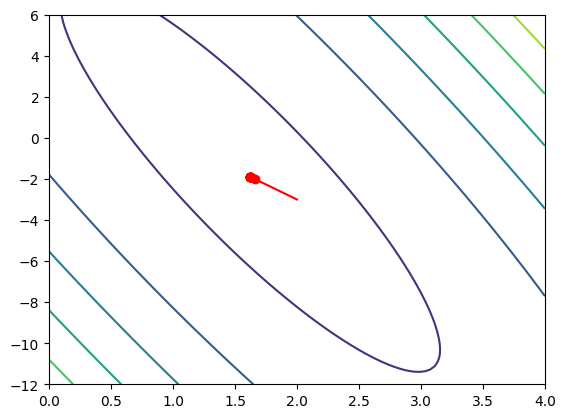

[[ 2.         -3.        ]
 [ 1.66036433 -2.00627182]
 [ 1.62640076 -1.906899  ]
 [ 1.6230044  -1.89696172]
 [ 1.62266477 -1.89596799]
 [ 1.6226308  -1.89586862]
 [ 1.62262741 -1.89585868]
 [ 1.62262707 -1.89585769]
 [ 1.62262703 -1.89585759]
 [ 1.62262703 -1.89585758]
 [ 1.62262703 -1.89585758]]


In [53]:
K = 10
# gamma = 0.1
gamma = 0.9
ab_newton_damped = damped_newton_rss2(K, a0, b0, X, Y, H, gamma, verbose=True)
print(ab_newton_damped)

In [54]:
print(rss2(a0, b0, X, Y))
print(rss2(ab_newton[-1, 0], ab_newton_damped[-1, 1], X, Y))

1427.6757139745007
1406.4905067721463


*Try different damping factors and interpret the effect. Your answer goes here!*

The regular and damped version of the newton method both seem to work extremely well. A larger damping factor makes the method "rush" towards the minimum with the aforementioned chance to overshoot while smaller damping factors make the method "crawl" and take it's time to arrive.